# Convpaint Workflow for Reverberation ROI

This notebook loads the same DICOM acquisition and hardcoded ROI used in the reverberation report, opens Napari for interactive label creation with Convpaint, and then applies a saved Convpaint model to generate a masked image.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pydicom
import napari

from napari_convpaint import ConvpaintWidget, ConvpaintModel
from napari.utils import nbscreenshot

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'gray'

In [2]:
# Same source and selection as reverberation_artifact_report.ipynb
repository_root = Path('..').resolve()
dicom_input_dir = repository_root / 'data' / 'ultrasound' / 'raices reales' / '1'
dicom_files = sorted(dicom_input_dir.glob('*.dcm'))

# Define paths for saving and loading
model_dir = repository_root / 'exploration' / 'models'
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'reverb_convpaint_model.pkl'
labels_path = model_dir / 'reverb_convpaint_labels.npy'

if len(dicom_files) == 0:
    raise FileNotFoundError(f'No DICOM files found in: {dicom_input_dir}')

selected_dicom_index = 0
selected_dicom_path = dicom_files[selected_dicom_index]
dataset = pydicom.dcmread(selected_dicom_path)
raw = dataset.pixel_array

if raw.ndim == 4:
    frames = raw[..., 0]
elif raw.ndim == 3:
    frames = raw
elif raw.ndim == 2:
    frames = raw[np.newaxis, ...]
else:
    raise ValueError(f'Unsupported DICOM pixel array shape: {raw.shape}')

# Same hardcoded ROI from the report
min_x, max_x = 401, 619
min_y, max_y = 116, 689

y0 = max(0, min_y)
y1 = min(frames.shape[1] - 1, max_y)
x0 = max(0, min_x)
x1 = min(frames.shape[2] - 1, max_x)

if y0 > y1 or x0 > x1:
    raise ValueError('Invalid ROI after clipping. Check min/max x/y values.')

roi_mask_2d = np.zeros(frames.shape[1:], dtype=bool)
roi_mask_2d[y0:y1 + 1, x0:x1 + 1] = True
volume = frames[:, y0:y1 + 1, x0:x1 + 1].astype(np.float32)

# try to laod annotations
annotations_dir = repository_root / 'exploration' / 'models' / 'reverb_convpaint_labels.npy'
if annotations_dir.exists():
    print(f'Loading previous annotations: {annotations_dir}')
    annotations = np.load(annotations_dir)
else:
    print('No previous annotations found')
    annotations = np.zeros_like(volume, dtype=np.uint16)

print(f'Loaded DICOM: {selected_dicom_path}')
print(f'frames shape: {frames.shape}, ROI volume shape: {volume.shape}')
print(f'Model will be saved at: {model_path}')
print(f'Annotations will be loaded from: {labels_path}')

Loading previous annotations: C:\Users\corba\Documents\eco-root\exploration\models\reverb_convpaint_labels.npy
Loaded DICOM: C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1\001.dcm
frames shape: (189, 768, 1024), ROI volume shape: (189, 574, 219)
Model will be saved at: C:\Users\corba\Documents\eco-root\exploration\models\reverb_convpaint_model.pkl
Annotations will be loaded from: C:\Users\corba\Documents\eco-root\exploration\models\reverb_convpaint_labels.npy


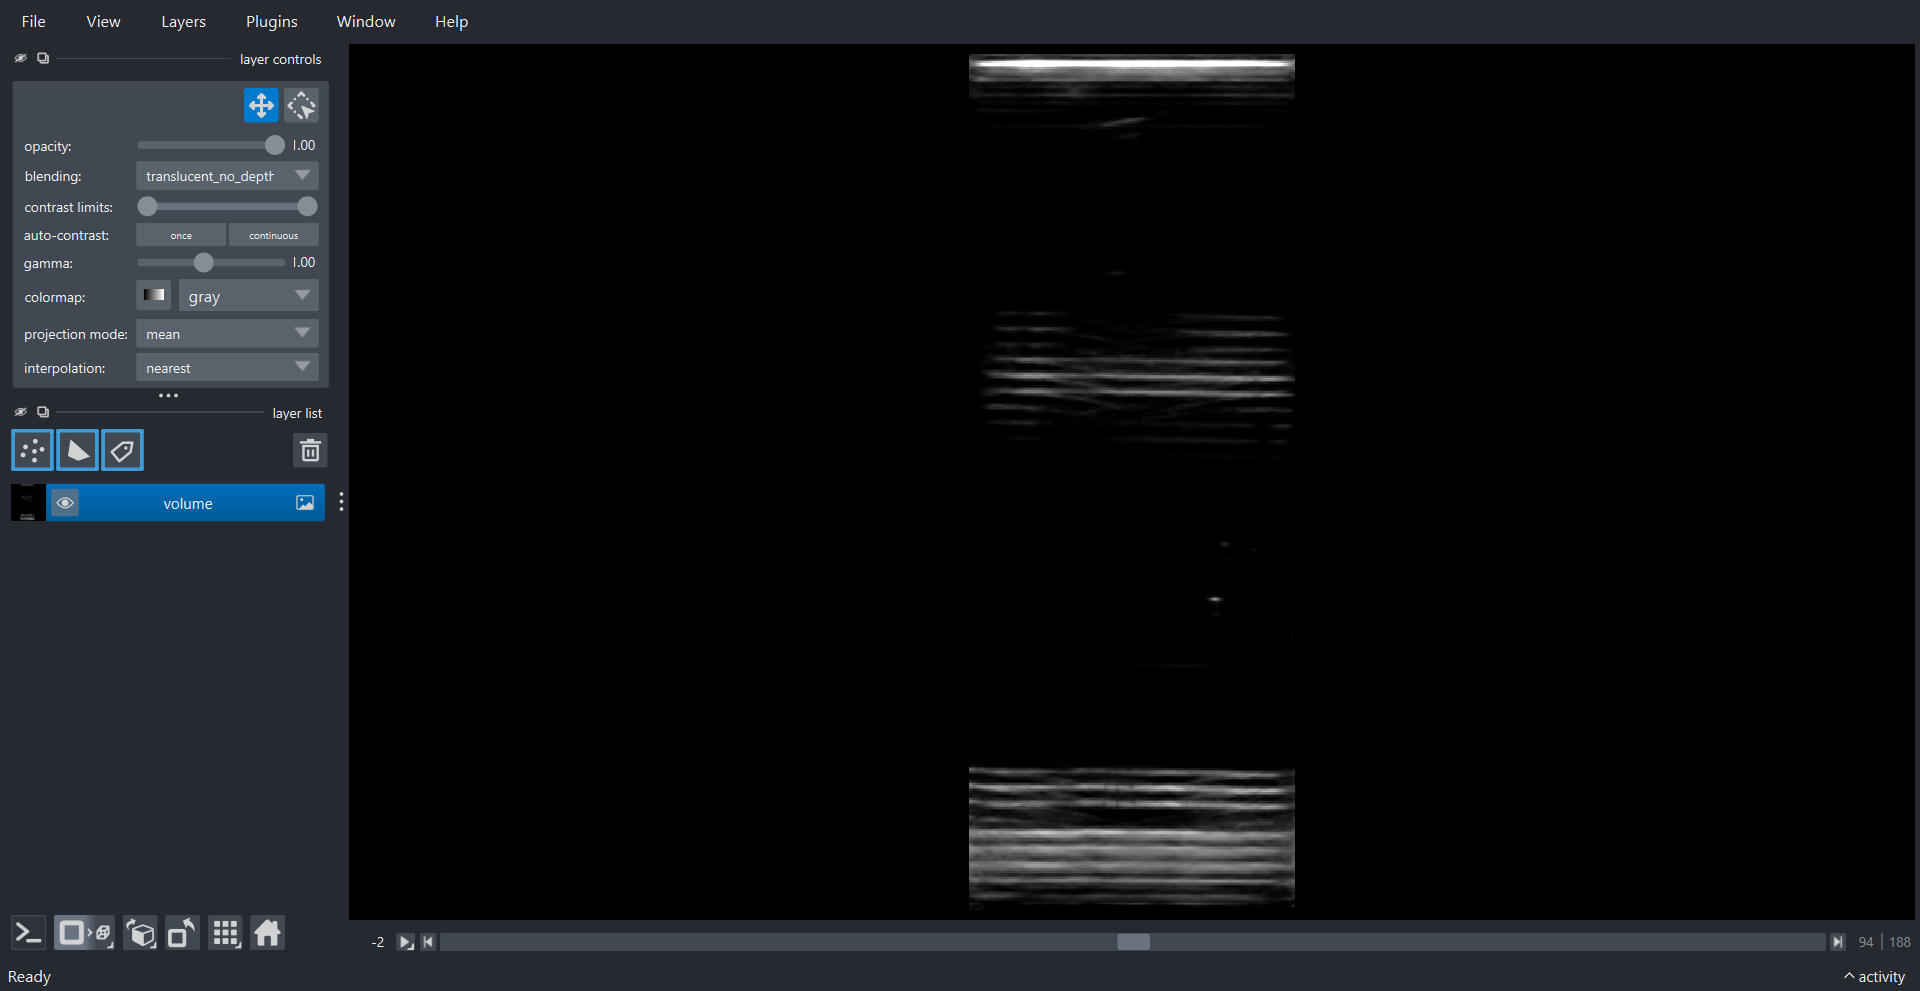

In [3]:
viewer = napari.Viewer(title='Convpaint Labeling - Reverberation ROI')
viewer.add_image(volume, name='volume', colormap='gray')

nbscreenshot(viewer)

## 1) Napari + Convpaint Labeling

Run the next cell to open Napari with the ROI frame and an empty labels layer.

In the Convpaint panel:
1. Select `roi_frame` as the image layer.
2. Use `convpaint_labels` to paint at least two classes (background = 0, artifact/object classes >= 1).
3. Train the model in the widget and save it to `exploration/models/reverb_convpaint_model.pkl`.

After training/saving in Napari, return and continue with the next cells.

In [ ]:
viewer = napari.Viewer(title='Convpaint Labeling - Reverberation ROI')
viewer.add_image(volume, name='volume', colormap='gray')
viewer.add_labels(annotations, name='annotations')

convpaint_widget = ConvpaintWidget(viewer)
viewer.window.add_dock_widget(convpaint_widget, area='right', name='Convpaint')

print('Napari is open with Convpaint widget.')
print('Paint labels, train in widget, and save model to:')
print(model_path)
print('Optional: save labels layer with next cell to:')
print(labels_path)

In [ ]:
if 'viewer' not in globals():
    raise RuntimeError('Run the Napari cell first so the viewer and labels layer exist.')

labels_data = np.asarray(viewer.layers['annotations'].data)
np.save(labels_path, labels_data)
print(f'Saved labels to: {labels_path}')
print(f'Non-zero labeled pixels: {int((labels_data > 0).sum())}')

## 2) Apply Saved Convpaint Model

The next cells load the saved model and generate a segmentation mask for the same ROI frame.

In [ ]:
model_path = model_path.with_name('20260619_3D_vgg16_6_features.pkl')

if not model_path.exists():
    raise FileNotFoundError(
        f'Model file not found at {model_path}. Train and save from the Convpaint widget first.'
    )

cp_model = ConvpaintModel(model_path=str(model_path))
segmentation = np.zeros_like(volume, dtype=np.int8)
for n, plane in enumerate(volume):
    segmentation[n] = cp_model.segment(plane)

# predicted_mask = segmentation > 0
print(f'Segmentation shape: {segmentation.shape}')
print(f'Predicted positive pixels: {int((segmentation > 0).sum())}')

In [5]:
viewer_results = napari.Viewer(title='Convpaint Results - Reverberation ROI')
viewer_results.add_image(volume, name='volume', colormap='gray')
viewer_results.add_labels(segmentation, name='segmentation', opacity=0.35)

nbscreenshot(viewer_results)

print('Napari results viewer opened.')
print('Layers: volume, convpaint_mask')

Napari results viewer opened.
Layers: volume, convpaint_mask


# 3) Mask the volume

If we use the newly generated segmentation to mask the volume we can keep what is most likely the object of interest. This can later be combined with the other views to further clean it up.

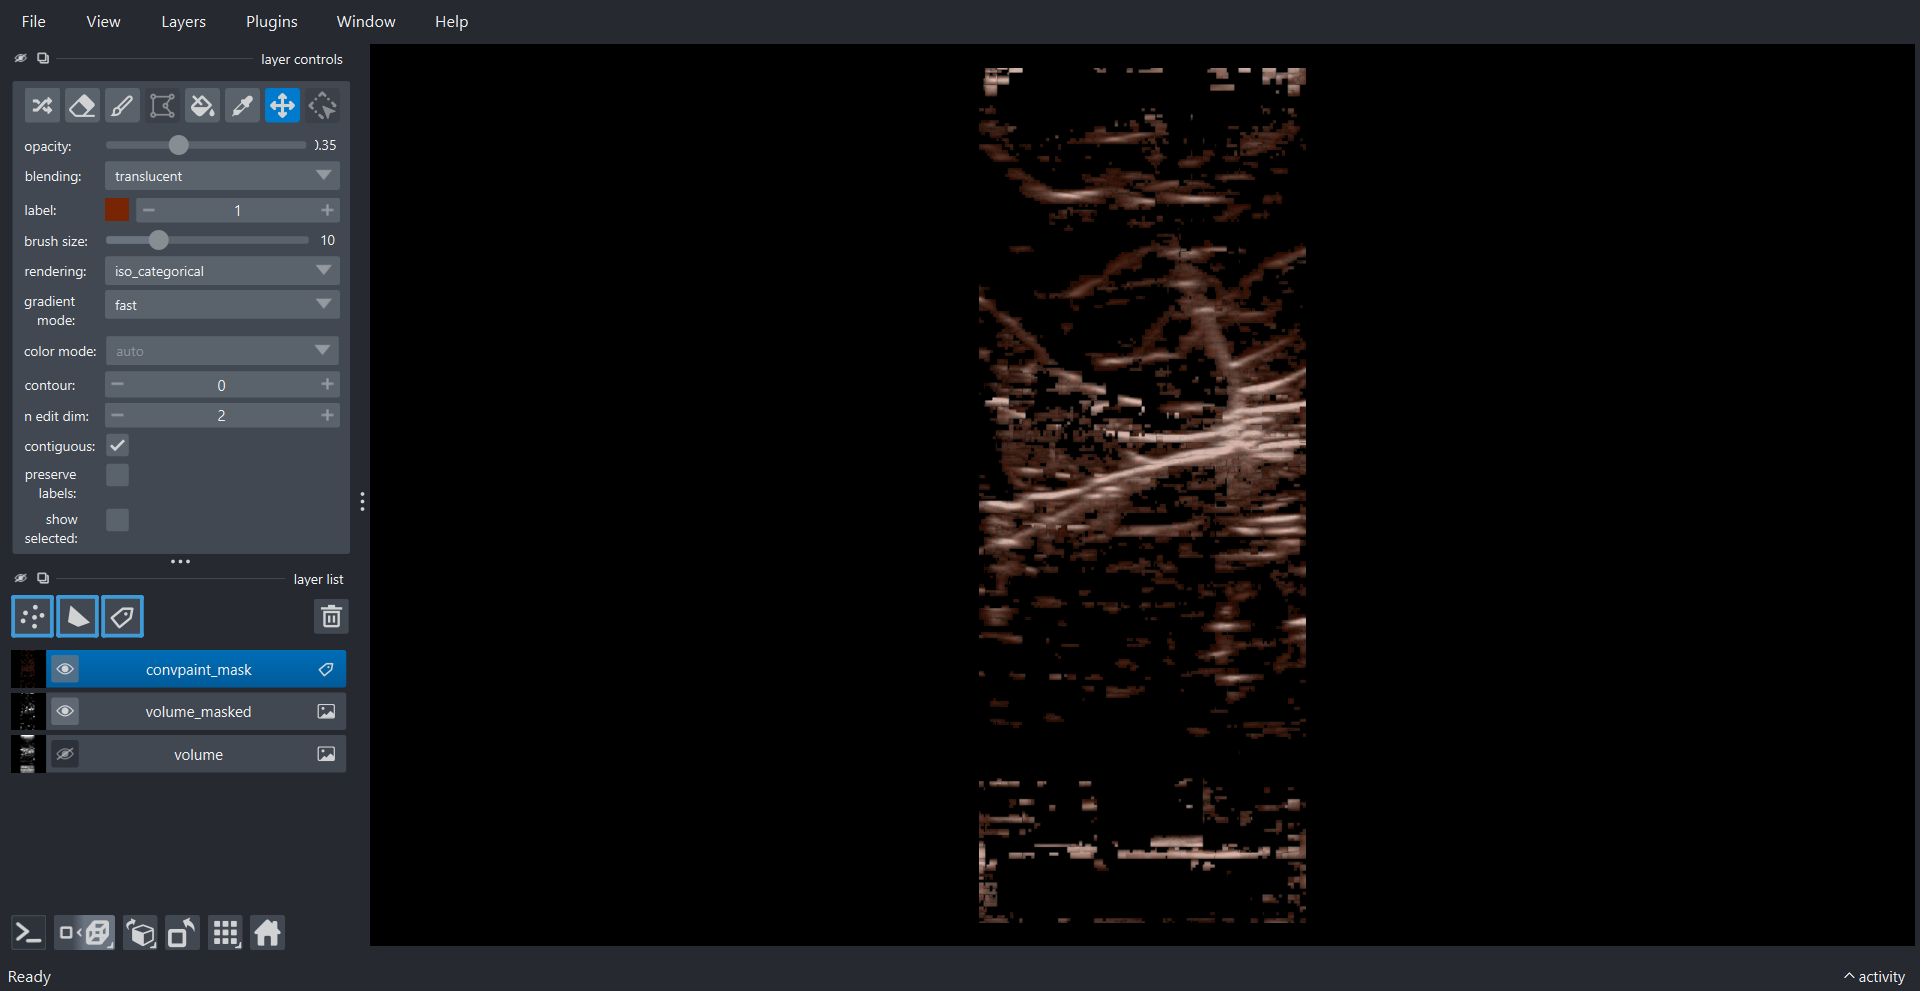

In [7]:
roots = segmentation == 3
volume_masked = np.zeros_like(volume)
volume_masked[roots] = volume[roots]

viewer_mask = napari.Viewer(title='Convpaint Mask - Reverberation ROI', ndisplay=3)
viewer_mask.add_image(volume, name='volume', colormap='gray')
viewer_mask.layers[-1].visible = False
viewer_mask.add_image(volume_masked, name='volume_masked', colormap='gray', visible=True)
viewer_mask.add_labels(roots, name='convpaint_mask', opacity=0.35)

nbscreenshot(viewer_mask)